In [1]:
!pip install kaggle opencv-python torch torchvision tqdm

/bin/bash: /home/solomo/anaconda3/envs/tf/lib/libtinfo.so.6: no version information available (required by /bin/bash)


In [2]:
import torch.nn as nn
import torchvision.models as models

class SpatialAttention(nn.Module):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        scale = torch.cat([avg_out, max_out], dim=1)
        scale = self.conv(scale)
        return x * self.sigmoid(scale)

class PretrainAttentionCNN(nn.Module):
    def __init__(self, feature_dim=512):
        super(PretrainAttentionCNN, self).__init__()
        
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(resnet.children())[:-2])
        
        self.attention = SpatialAttention()
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # REMOVE SIGMOID
        self.temp_classifier = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.pool(x)

        features = x.view(x.size(0), -1)

        return features  #  RETURN FEATURES ONLY

    def classify(self, features):
        return self.temp_classifier(features)

In [3]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model=512, max_len=8):   
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class SequenceDrowsinessModel(nn.Module):
    def __init__(self, pretrained_cnn, seq_length=8, feature_dim=512, num_heads=8, num_layers=2):  
        super(SequenceDrowsinessModel, self).__init__()
        
        self.cnn = pretrained_cnn
        
        
        
        self.pos_encoder = PositionalEncoding(d_model=feature_dim, max_len=seq_length)
        
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=feature_dim,
                nhead=num_heads,
                batch_first=True,
                dropout=0.3
            ),
            num_layers=num_layers
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        B, S, C, H, W = x.size()
        
        x = x.view(B * S, C, H, W)
        
        features = self.cnn(x)   # (B*S, 512)
        
        sequence_features = features.view(B, S, -1)  # (B, S, 512)
        
        sequence_features = self.pos_encoder(sequence_features)
        
        transformer_out = self.transformer(sequence_features)
        
        temporal_representation = transformer_out.mean(dim=1)
        
        out = self.classifier(temporal_representation)
        
        return out

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CNN
cnn_backbone = PretrainAttentionCNN(feature_dim=512)
cnn_backbone.load_state_dict(torch.load("pretrained_attention_cnn.pth", map_location=device))

# Load full model
model = SequenceDrowsinessModel(
    pretrained_cnn=cnn_backbone,
    seq_length=8
).to(device)

model.load_state_dict(torch.load("final_attention_cnn_transformer_v3.pth", map_location=device))
model.eval()

print("✅ Model loaded once and ready")

✅ Model loaded once and ready


In [5]:
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class NTHUSequenceDataset(Dataset):
    def __init__(self, root_dir, transform=None, seq_len=8):
        self.transform = transform
        self.seq_len = seq_len
        self.samples = []

        class_map = {
            "alert": 0,
            "drowsy": 1
        }

        for class_name, label in class_map.items():
            class_path = os.path.join(root_dir, class_name)

            images = sorted(glob.glob(os.path.join(class_path, "**/*.jpg"), recursive=True))

            for i in range(len(images) - seq_len):
                seq = images[i:i+seq_len]
                self.samples.append((seq, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label = self.samples[idx]

        sequence = []
        for path in frame_paths:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            sequence.append(img)

        return torch.stack(sequence), torch.tensor(label, dtype=torch.float32)


# SAME TRANSFORM AS TRAINING
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

dataset = NTHUSequenceDataset("dataset/nthu_processed", transform=transform, seq_len=8)

#  ONLY NEED VAL LOADER
val_loader = DataLoader(dataset, batch_size=8, shuffle=False)

print("Dataset loaded:", len(dataset))

Dataset loaded: 66505


In [6]:
import cv2
from torchvision import transforms
from PIL import Image
from collections import deque
import numpy as np

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])

def quick_video_check(video_path):
    cap = cv2.VideoCapture(video_path)

    frame_buffer = deque(maxlen=8)
    frame_count = 0

    probs = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # sample frames
        if frame_count % 3 == 0:
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(img_rgb)

            tensor_img = transform(img)
            frame_buffer.append(tensor_img)

        if len(frame_buffer) == 8:
            seq = torch.stack(list(frame_buffer)).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(seq)
                prob = torch.sigmoid(output).item()

            probs.append(prob)

    cap.release()

    if len(probs) == 0:
        print(" Not enough frames")
        return

    avg_prob = sum(probs) / len(probs)

    label = "DROWSY" if avg_prob > 0.5 else "ALERT"

    print(f"\n🎯 RESULT: {label} ({avg_prob:.2f})\n")

In [7]:
quick_video_check("dataset/WhatsApp Video 2026-03-29 at 15.32.51.mp4")


🎯 RESULT: DROWSY (0.82)



/home/solomo/anaconda3/envs/tf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Running inference on validation set...


Evaluating Batches: 100%|██████████| 8314/8314 [22:01<00:00,  6.29batch/s]



📊 OVERALL EVALUATION METRICS
Accuracy  : 0.8995
Precision : 0.8523
Recall    : 0.9853
F1 Score  : 0.9140

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Alert (0)       0.98      0.80      0.88     30483
  Drowsy (1)       0.85      0.99      0.91     36022

    accuracy                           0.90     66505
   macro avg       0.92      0.89      0.90     66505
weighted avg       0.91      0.90      0.90     66505



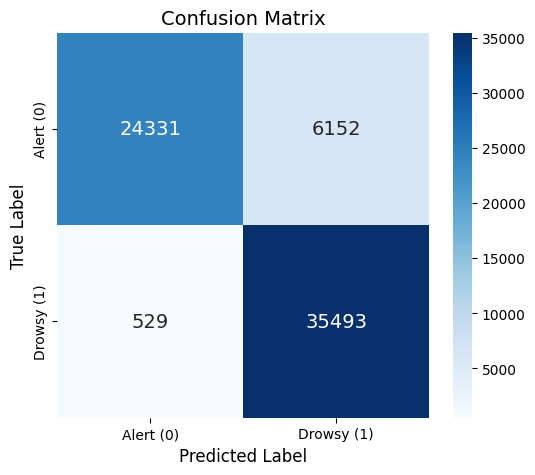

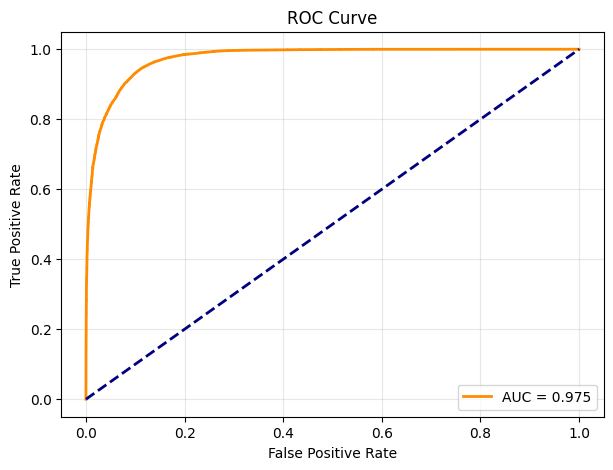

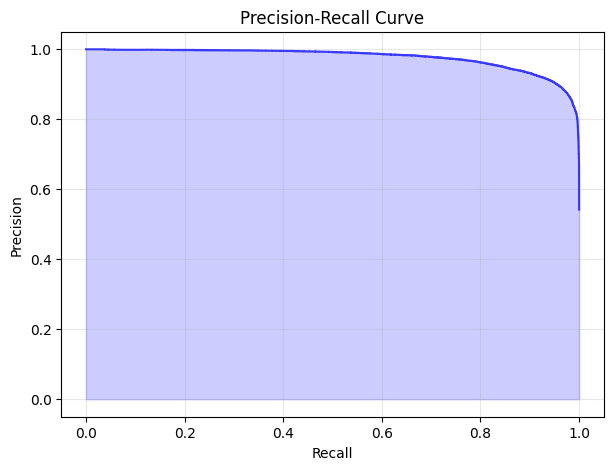

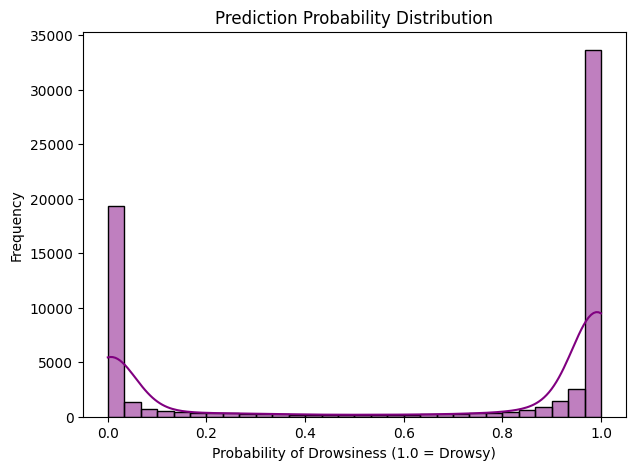

In [8]:
from sklearn.metrics import (
    classification_report, roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm  # <-- Added tqdm import

def evaluate_model_everything(model, dataloader, device):
    print("⏳ Running inference on validation set...")
    model.eval()
    
    all_probs = []
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        # <-- Wrapped the dataloader in tqdm
        for images, labels in tqdm(dataloader, desc="Evaluating Batches", unit="batch"):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs_batch = torch.sigmoid(outputs).squeeze()
            
            if probs_batch.dim() == 0:
                probs_batch = probs_batch.unsqueeze(0)
                
            preds_batch = (probs_batch > 0.5).int()

            all_probs.extend(probs_batch.cpu().numpy())
            all_preds.extend(preds_batch.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    probs = np.array(all_probs)
    preds = np.array(all_preds)
    labels = np.array(all_labels)
    
    # ==========================================
    # 1. SCALAR METRICS & CLASSIFICATION REPORT
    # ==========================================
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    
    print("\n" + "="*40)
    print("📊 OVERALL EVALUATION METRICS")
    print("="*40)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    
    print("\n" + "="*40)
    print("CLASSIFICATION REPORT")
    print("="*40)
    print(classification_report(labels, preds, target_names=["Alert (0)", "Drowsy (1)"]))

    # ==========================================
    # 2. CONFUSION MATRIX
    # ==========================================
    cm = confusion_matrix(labels, preds)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Alert (0)', 'Drowsy (1)'],
                yticklabels=['Alert (0)', 'Drowsy (1)'],
                annot_kws={"size": 14})
    
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title("Confusion Matrix", fontsize=14)
    plt.show()

    # ==========================================
    # 3. ROC CURVE & AUC
    # ==========================================
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    # ==========================================
    # 4. PRECISION-RECALL CURVE
    # ==========================================
    precision, recall, _ = precision_recall_curve(labels, probs)

    plt.figure(figsize=(7, 5))
    plt.step(recall, precision, color='b', alpha=0.7, where='post')
    plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.grid(alpha=0.3)
    plt.show()

    # ==========================================
    # 5. PREDICTION PROBABILITY DISTRIBUTION
    # ==========================================
    plt.figure(figsize=(7, 5))
    sns.histplot(probs, bins=30, kde=True, color="purple")
    plt.title("Prediction Probability Distribution")
    plt.xlabel("Probability of Drowsiness (1.0 = Drowsy)")
    plt.ylabel("Frequency")
    plt.show()
    
    return probs, preds, labels, cm, acc, prec, rec, f1

# Run the function 
probs, preds, labels, cm, acc, prec, rec, f1 = evaluate_model_everything(model, val_loader, device)

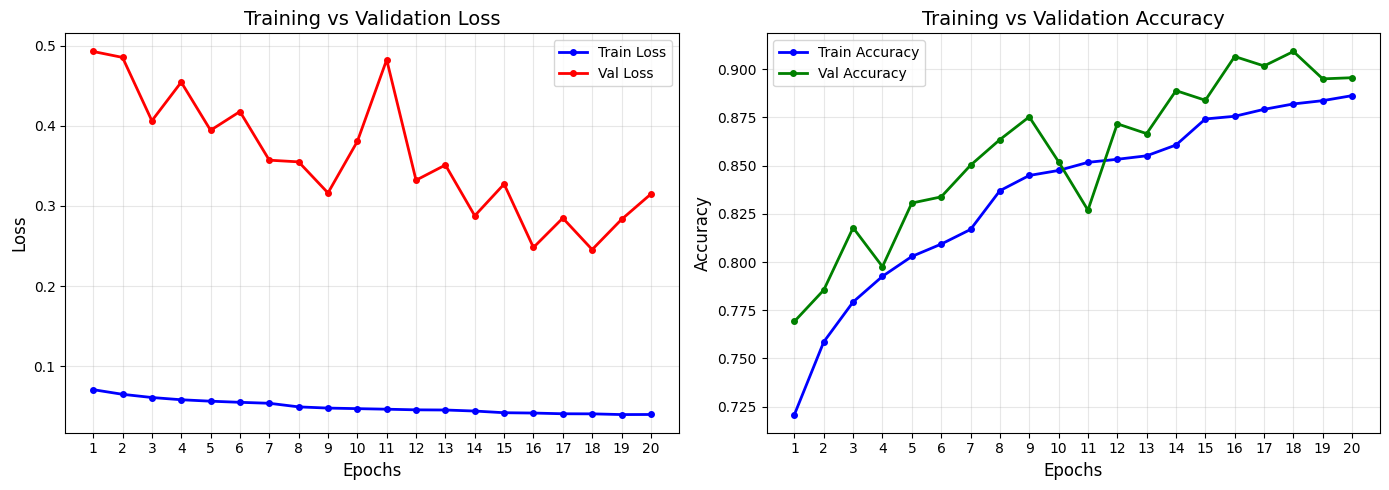

In [9]:
import matplotlib.pyplot as plt

# Extracted from your logs
epochs = list(range(1, 21))

# Losses
train_loss = [0.0706, 0.0648, 0.0608, 0.0580, 0.0562, 0.0548, 0.0536, 0.0491, 0.0476, 0.0469, 
              0.0462, 0.0454, 0.0452, 0.0439, 0.0418, 0.0414, 0.0405, 0.0404, 0.0395, 0.0396]

val_loss = [0.4928, 0.4854, 0.4063, 0.4545, 0.3944, 0.4178, 0.3571, 0.3550, 0.3162, 0.3805, 
            0.4825, 0.3321, 0.3511, 0.2877, 0.3273, 0.2481, 0.2848, 0.2455, 0.2831, 0.3148]

# Accuracies
train_acc = [0.7209, 0.7586, 0.7793, 0.7926, 0.8029, 0.8093, 0.8169, 0.8370, 0.8449, 0.8475, 
             0.8517, 0.8533, 0.8551, 0.8607, 0.8742, 0.8756, 0.8792, 0.8820, 0.8837, 0.8863]

val_acc = [0.7692, 0.7855, 0.8178, 0.7976, 0.8306, 0.8338, 0.8502, 0.8635, 0.8753, 0.8520, 
           0.8269, 0.8717, 0.8666, 0.8889, 0.8839, 0.9066, 0.9017, 0.9092, 0.8950, 0.8956]


# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss Curve
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', lw=2, markersize=4)
ax1.plot(epochs, val_loss, 'r-o', label='Val Loss', lw=2, markersize=4)
ax1.set_title('Training vs Validation Loss', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.grid(alpha=0.3)
ax1.legend()

# 2. Accuracy Curve
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', lw=2, markersize=4)
ax2.plot(epochs, val_acc, 'g-o', label='Val Accuracy', lw=2, markersize=4)
ax2.set_title('Training vs Validation Accuracy', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xticks(epochs)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()